In [ ]:
# ── Install dependencies ──────────────────────────────────────────────
!pip install -q kagglehub opencv-python-headless scikit-learn

In [ ]:
# ── Download DrishtiGS dataset via kagglehub ──────────────────────────
import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    "lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation"
)

print("Dataset downloaded to:", dataset_path)


100%|██████████| 341M/341M [00:01<00:00, 198MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/versions/1


In [ ]:
# ── Explore folder structure ───────────────────────────────────────────
import os

for root, dirs, files in os.walk(dataset_path):
    # Skip deeply nested empty dirs
    level = root.replace(dataset_path, '').count(os.sep)
    if level < 5 and files:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")


        glaucoma/  (38 files)
        normal/  (13 files)
        drishtiGS_020/  (1 files)
        drishtiGS_007/  (1 files)
        drishtiGS_079/  (1 files)
        drishtiGS_083/  (1 files)
        drishtiGS_034/  (1 files)
        drishtiGS_054/  (1 files)
        drishtiGS_091/  (1 files)
        drishtiGS_048/  (1 files)
        drishtiGS_059/  (1 files)
        drishtiGS_100/  (1 files)
        drishtiGS_052/  (1 files)
        drishtiGS_095/  (1 files)
        drishtiGS_093/  (1 files)
        drishtiGS_056/  (1 files)
        drishtiGS_001/  (1 files)
        drishtiGS_071/  (1 files)
        drishtiGS_023/  (1 files)
        drishtiGS_085/  (1 files)
        drishtiGS_072/  (1 files)
        drishtiGS_077/  (1 files)
        drishtiGS_009/  (1 files)
        drishtiGS_011/  (1 files)
        drishtiGS_078/  (1 files)
        drishtiGS_055/  (1 files)
        drishtiGS_065/  (1 files)
        drishtiGS_067/  (1 files)
        drishtiGS_097/  (1 files)
        drishtiGS_043/  

In [ ]:
# ── Collect training image & mask paths ───────────────────────────────
from glob import glob
import os

# ---- Training Images ----
glaucoma_images = glob(
    os.path.join(dataset_path, "**/Training/Images/GLAUCOMA/*.png"),
    recursive=True
)
normal_images = glob(
    os.path.join(dataset_path, "**/Training/Images/NORMAL/*.png"),
    recursive=True
)
# Fallback: case-insensitive directory names (Glaucoma / Normal)
if not glaucoma_images:
    glaucoma_images = glob(os.path.join(dataset_path, "**/Training/Images/Glaucoma/*.png"), recursive=True)
if not normal_images:
    normal_images = glob(os.path.join(dataset_path, "**/Training/Images/Normal/*.png"), recursive=True)

image_paths = glaucoma_images + normal_images
print("Training Images:", len(image_paths))

# ---- Training Masks ----
mask_paths = []
for img_path in image_paths:
    image_name = os.path.basename(img_path).replace(".png", "")
    candidates = glob(
        os.path.join(dataset_path, f"**/GT/{image_name}/SoftMap/*ODsegSoftmap.png"),
        recursive=True
    )
    if candidates:
        mask_paths.append(candidates[0])

print("Training Masks:", len(mask_paths))

# Keep only images that have a matching mask
paired = [(i, m) for i, m in zip(image_paths, mask_paths)]
image_paths = [p[0] for p in paired]
mask_paths  = [p[1] for p in paired]

print("\nExample Image:", image_paths[0])
print("Example Mask :", mask_paths[0])


Training Images: 50
Training Masks: 50

Example Image: /root/.cache/kagglehub/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/versions/1/Training-20211018T055246Z-001/Training/Images/GLAUCOMA/drishtiGS_062.png
Example Mask : /root/.cache/kagglehub/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/versions/1/Training-20211018T055246Z-001/Training/GT/drishtiGS_062/SoftMap/drishtiGS_062_ODsegSoftmap.png


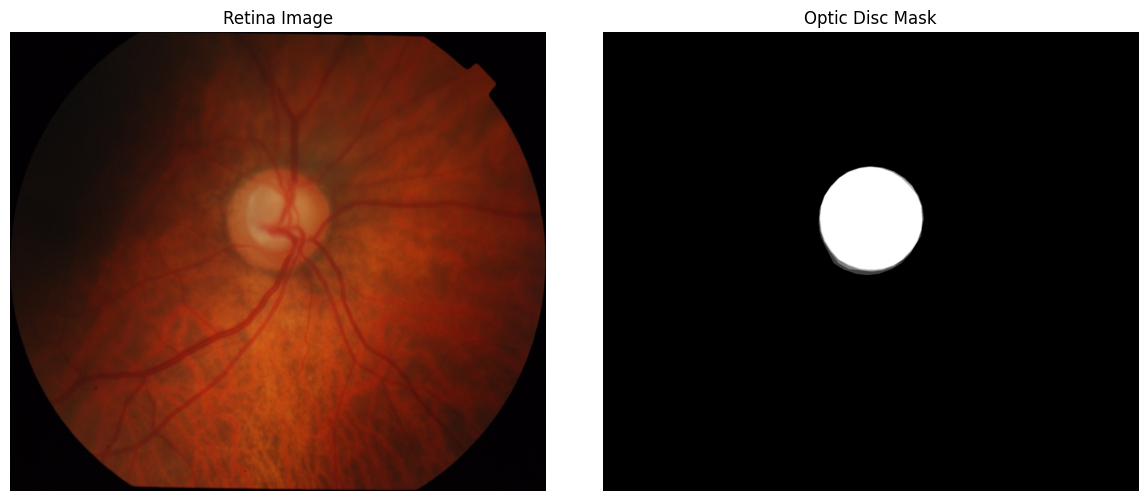

In [ ]:
# ── Visualise one image + mask ─────────────────────────────────────────
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_paths[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask  = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(image);             plt.title("Retina Image");     plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(mask, cmap='gray'); plt.title("Optic Disc Mask"); plt.axis("off")
plt.tight_layout(); plt.show()


In [ ]:
# ── PyTorch Dataset ────────────────────────────────────────────────────
from torch.utils.data import Dataset
import torch
import cv2
import numpy as np


class RetinaDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))
        image = (image / 255.0).astype(np.float32)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (256, 256))
        mask = (mask > 127).astype(np.float32)

        image = torch.tensor(image).permute(2, 0, 1)
        mask  = torch.tensor(mask).unsqueeze(0)
        return image, mask


dataset = RetinaDataset(image_paths, mask_paths)
print("Dataset Length:", len(dataset))

# Quick shape check
img, msk = dataset[0]
print("Image Shape:", img.shape, "| Mask Shape:", msk.shape)


Dataset Length: 50
Image Shape: torch.Size([3, 256, 256]) | Mask Shape: torch.Size([1, 256, 256])


In [ ]:
# ── Train / Validation split ───────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_dataset = RetinaDataset(train_images, train_masks)
val_dataset   = RetinaDataset(val_images,   val_masks)

print("Train:", len(train_dataset), "| Val:", len(val_dataset))


Train: 40 | Val: 10


In [ ]:
# ── DataLoaders ────────────────────────────────────────────────────────
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)

print("Train Batches:", len(train_loader), "| Val Batches:", len(val_loader))

# Batch shape sanity check
imgs, msks = next(iter(train_loader))
print("Batch – Images:", imgs.shape, "| Masks:", msks.shape)


Train Batches: 10 | Val Batches: 3
Batch – Images: torch.Size([4, 3, 256, 256]) | Masks: torch.Size([4, 1, 256, 256])


In [ ]:
# ── U-Net Model ────────────────────────────────────────────────────────
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1    = DoubleConv(3,   64);  self.pool1 = nn.MaxPool2d(2)
        self.down2    = DoubleConv(64,  128); self.pool2 = nn.MaxPool2d(2)
        self.down3    = DoubleConv(128, 256); self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2); self.conv3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2); self.conv2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128,  64, 2, stride=2); self.conv1 = DoubleConv(128,  64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.down1(x);    p1 = self.pool1(c1)
        c2 = self.down2(p1);   p2 = self.pool2(c2)
        c3 = self.down3(p2);   p3 = self.pool3(c3)
        bn = self.bottleneck(p3)
        u3 = self.conv3(torch.cat([self.up3(bn), c3], dim=1))
        u2 = self.conv2(torch.cat([self.up2(u3), c2], dim=1))
        u1 = self.conv1(torch.cat([self.up1(u2), c1], dim=1))
        return self.final(u1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet().to(device)
print("U-Net loaded successfully!")


Using device: cuda
U-Net loaded successfully!


In [ ]:
# ── Loss & Optimiser ───────────────────────────────────────────────────
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
print("Loss: BCEWithLogitsLoss | Optimizer: Adam (lr=1e-4)")


Loss: BCEWithLogitsLoss | Optimizer: Adam (lr=1e-4)


In [ ]:
# ── Training loop (30 epochs total) ────────────────────────────────────
num_epochs  = 30
train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    # -- Train --
    model.train()
    train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss    = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # -- Validate --
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            val_loss += criterion(model(images), masks).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    print(f"Epoch [{epoch+1:>2}/{num_epochs}]  "
          f"Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}")


Epoch [ 1/30]  Train Loss: 0.6448  Val Loss: 0.6327
Epoch [ 2/30]  Train Loss: 0.6160  Val Loss: 0.5837
Epoch [ 3/30]  Train Loss: 0.4091  Val Loss: 0.2880
Epoch [ 4/30]  Train Loss: 0.2260  Val Loss: 0.1777
Epoch [ 5/30]  Train Loss: 0.1783  Val Loss: 0.1600
Epoch [ 6/30]  Train Loss: 0.1453  Val Loss: 0.1243
Epoch [ 7/30]  Train Loss: 0.1164  Val Loss: 0.1023
Epoch [ 8/30]  Train Loss: 0.1019  Val Loss: 0.0965
Epoch [ 9/30]  Train Loss: 0.0960  Val Loss: 0.0899
Epoch [10/30]  Train Loss: 0.0950  Val Loss: 0.0833
Epoch [11/30]  Train Loss: 0.0868  Val Loss: 0.0829
Epoch [12/30]  Train Loss: 0.0858  Val Loss: 0.0766
Epoch [13/30]  Train Loss: 0.0859  Val Loss: 0.0829
Epoch [14/30]  Train Loss: 0.0807  Val Loss: 0.0709
Epoch [15/30]  Train Loss: 0.0755  Val Loss: 0.0635
Epoch [16/30]  Train Loss: 0.0709  Val Loss: 0.0612
Epoch [17/30]  Train Loss: 0.0743  Val Loss: 0.0562
Epoch [18/30]  Train Loss: 0.0659  Val Loss: 0.0813
Epoch [19/30]  Train Loss: 0.0674  Val Loss: 0.0538
Epoch [20/30

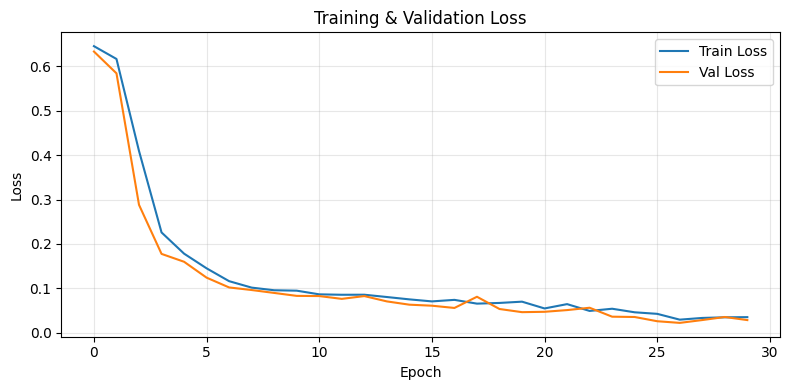

In [ ]:
# ── Loss curve ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# ── Collect test image & mask paths ────────────────────────────────────
import os, glob as gl

test_image_paths = (
    gl.glob(os.path.join(dataset_path, "**/Test/Images/glaucoma/*.png"), recursive=True) +
    gl.glob(os.path.join(dataset_path, "**/Test/Images/Glaucoma/*.png"), recursive=True) +
    gl.glob(os.path.join(dataset_path, "**/Test/Images/normal/*.png"),   recursive=True) +
    gl.glob(os.path.join(dataset_path, "**/Test/Images/Normal/*.png"),   recursive=True)
)
print("Test Images found:", len(test_image_paths))

test_mask_paths = []
for img_path in test_image_paths:
    img_name = os.path.basename(img_path).replace(".png", "")
    # Try both Test_GT and GT folder naming variants
    candidates = (
        gl.glob(os.path.join(dataset_path, f"**/Test_GT/{img_name}/SoftMap/*ODsegSoftmap.png"), recursive=True) +
        gl.glob(os.path.join(dataset_path, f"**/GT/{img_name}/SoftMap/*ODsegSoftmap.png"),      recursive=True)
    )
    if candidates:
        test_mask_paths.append(candidates[0])

print("Test Masks found :", len(test_mask_paths))

test_dataset = RetinaDataset(test_image_paths, test_mask_paths)
print("Test Dataset     :", len(test_dataset))


Test Images found: 51
Test Masks found : 51
Test Dataset     : 51


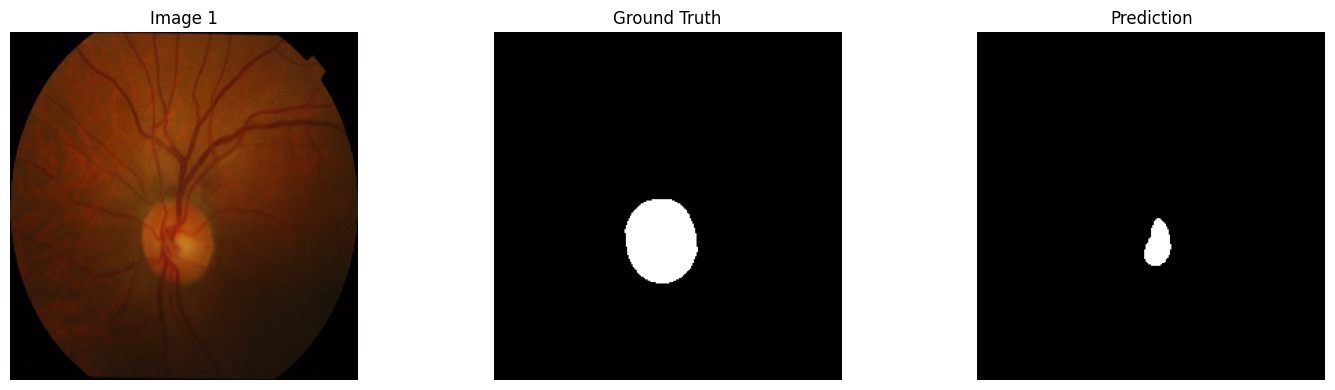

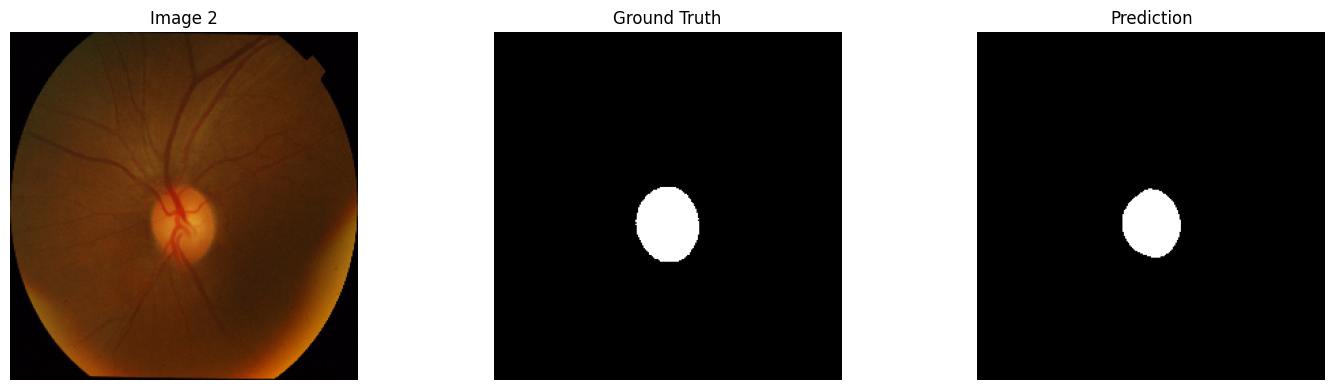

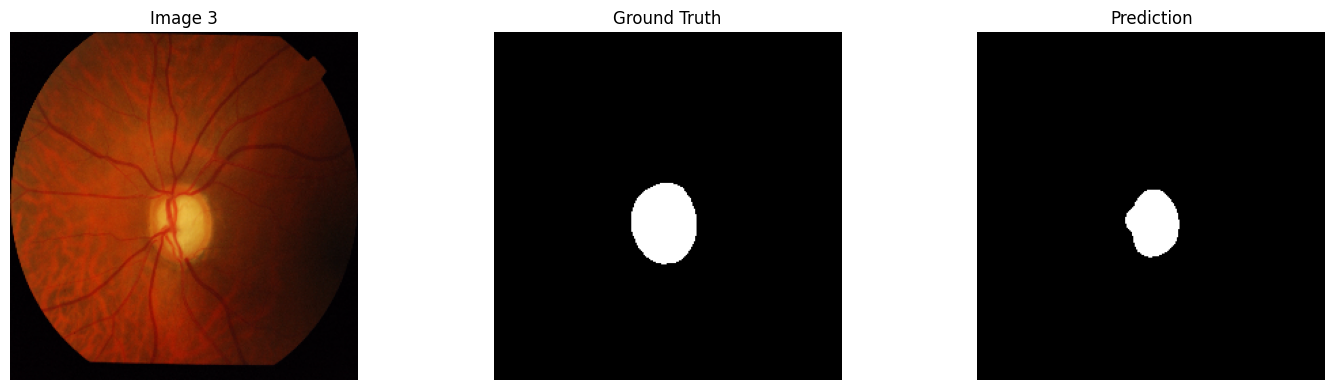

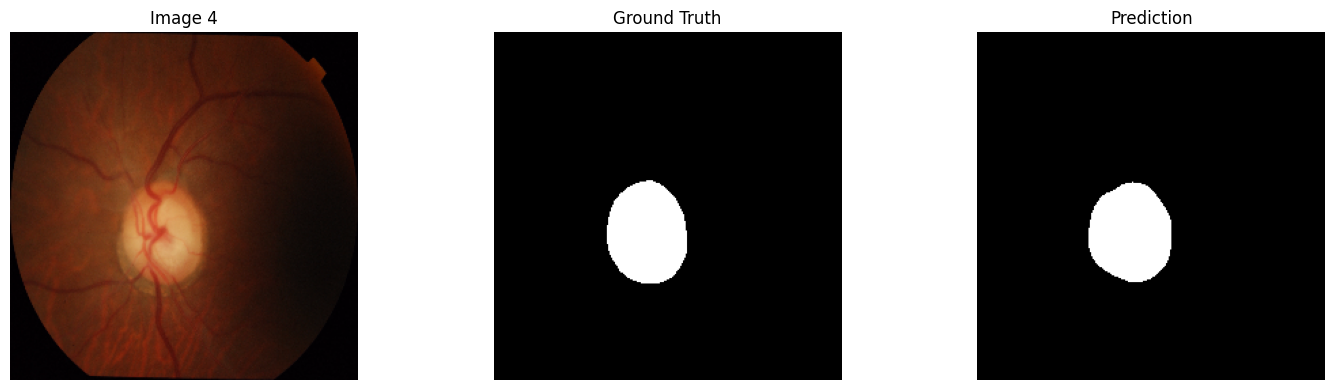

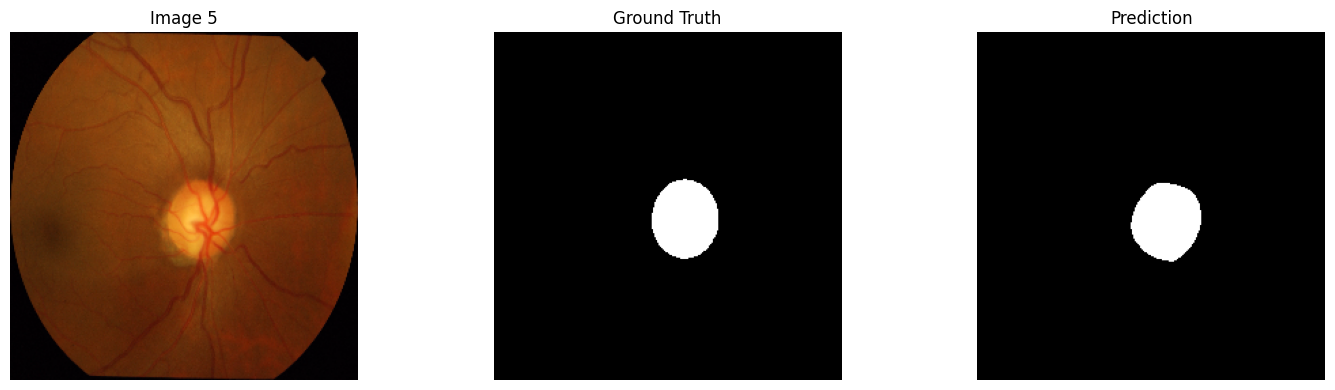

In [ ]:
# ── Visualise 5 test predictions ───────────────────────────────────────
model.eval()
for i in range(min(5, len(test_dataset))):
    image, true_mask = test_dataset[i]
    with torch.no_grad():
        pred = torch.sigmoid(model(image.unsqueeze(0).to(device)))
    pred = (pred > 0.5).float()

    img_np  = image.permute(1,2,0).numpy()
    mask_np = true_mask.squeeze().numpy()
    pred_np = pred.squeeze().cpu().numpy()

    plt.figure(figsize=(15, 4))
    plt.subplot(1,3,1); plt.imshow(img_np);             plt.title(f"Image {i+1}");     plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask_np,cmap='gray');plt.title("Ground Truth");     plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pred_np,cmap='gray');plt.title("Prediction");       plt.axis("off")
    plt.tight_layout(); plt.show()


In [ ]:
# ── Save model weights ─────────────────────────────────────────────────
torch.save(model.state_dict(), "optic_disc_unet.pth")
print("Model saved as optic_disc_unet.pth")


Model saved as optic_disc_unet.pth


In [ ]:
# ── 1. Collect predictions over the entire test set ───────────────────
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

model.eval()

all_true  = []   # flattened binary ground-truth pixels
all_probs = []   # flattened sigmoid probabilities  (for ROC-AUC)
all_preds = []   # flattened binary predictions     (threshold = 0.5)

with torch.no_grad():
    for image, mask in test_dataset:
        image_t = image.unsqueeze(0).to(device)
        logits  = model(image_t)
        prob    = torch.sigmoid(logits)      # (1,1,H,W)
        pred    = (prob > 0.5).float()       # binary mask

        all_true.append(mask.numpy().flatten())
        all_probs.append(prob.cpu().numpy().flatten())
        all_preds.append(pred.cpu().numpy().flatten())

y_true = np.concatenate(all_true)
y_prob = np.concatenate(all_probs)
y_pred = np.concatenate(all_preds)

print("Total pixels evaluated:", len(y_true))

# ── 2. Confusion-matrix derived metrics ───────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

precision   = tp / (tp + fp + 1e-7)
recall      = tp / (tp + fn + 1e-7)      # = TPR
tpr         = recall
fpr         = fp / (fp + tn + 1e-7)
specificity = tn / (tn + fp + 1e-7)
f1          = 2 * precision * recall / (precision + recall + 1e-7)
dice        = f1                          # identical for binary segmentation
roc_auc     = roc_auc_score(y_true, y_prob)

# ── 3. Summary table ──────────────────────────────────────────────────
print("\n" + "="*45)
print(f"{'METRIC':<25} {'VALUE':>10}")
print("="*45)
print(f"{'Precision':<25} {precision:>10.4f}")
print(f"{'Recall (TPR)':<25} {tpr:>10.4f}")
print(f"{'False Positive Rate':<25} {fpr:>10.4f}")
print(f"{'Specificity (TNR)':<25} {specificity:>10.4f}")
print(f"{'F1-Score':<25} {f1:>10.4f}")
print(f"{'Dice Score':<25} {dice:>10.4f}")
print(f"{'ROC-AUC':<25} {roc_auc:>10.4f}")
print("="*45)


Total pixels evaluated: 3342336

METRIC                         VALUE
Precision                     0.9635
Recall (TPR)                  0.6628
False Positive Rate           0.0008
Specificity (TNR)             0.9992
F1-Score                      0.7854
Dice Score                    0.7854
ROC-AUC                       0.9960


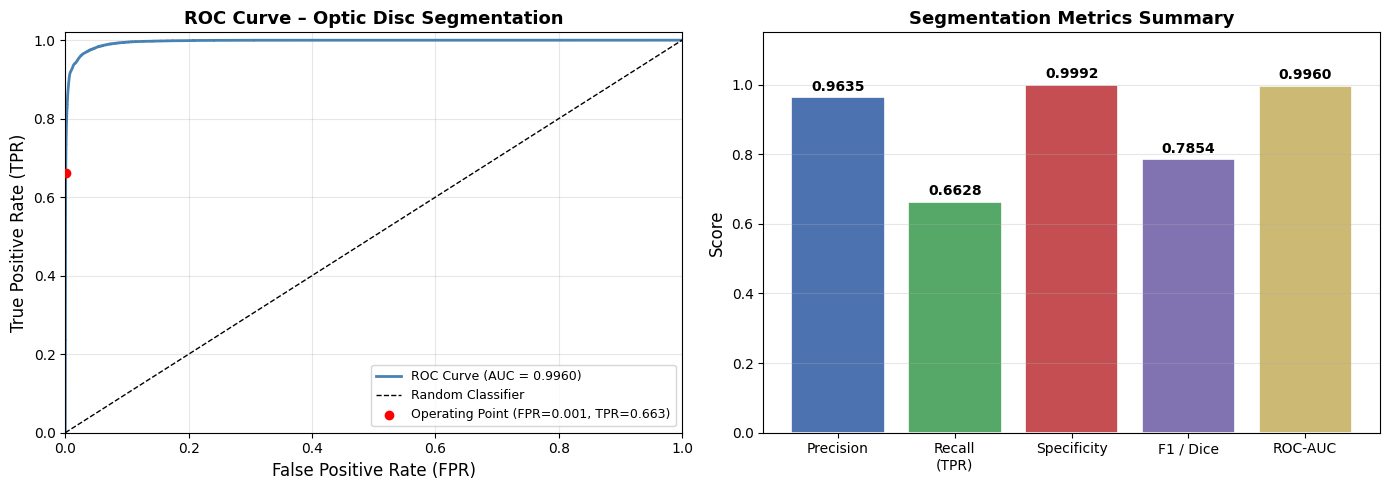

Figure saved as metrics_summary.png


In [ ]:
# ── 4. ROC Curve + Metrics bar chart ──────────────────────────────────

# Subsample for speed on large pixel arrays
SAMPLE_SIZE = 500_000
if len(y_true) > SAMPLE_SIZE:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(y_true), SAMPLE_SIZE, replace=False)
    fpr_curve, tpr_curve, _ = roc_curve(y_true[idx], y_prob[idx])
else:
    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC curve
axes[0].plot(fpr_curve, tpr_curve, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].scatter([fpr], [tpr], color='red', zorder=5,
                label=f'Operating Point (FPR={fpr:.3f}, TPR={tpr:.3f})')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Curve – Optic Disc Segmentation', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# Right: bar chart of all metrics
names  = ['Precision', 'Recall\n(TPR)', 'Specificity', 'F1 / Dice', 'ROC-AUC']
values = [precision, tpr, specificity, f1, roc_auc]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = axes[1].bar(names, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim([0, 1.15])
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Segmentation Metrics Summary', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as metrics_summary.png')


In [ ]:
# ── 5. Per-image metrics (first 10 test samples) ──────────────────────
model.eval()

print(f"{'Img':<5} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Dice':>8} {'TPR':>8} {'FPR':>8}")
print("-" * 60)

with torch.no_grad():
    for i in range(min(10, len(test_dataset))):
        image, mask = test_dataset[i]
        logits = model(image.unsqueeze(0).to(device))
        prob   = torch.sigmoid(logits)
        pred   = (prob > 0.5).float()

        y_t = mask.numpy().flatten().astype(int)
        y_p = pred.cpu().numpy().flatten().astype(int)

        if y_t.sum() == 0 and y_p.sum() == 0:
            p, r, f, d, tpr_i, fpr_i = 1.0, 1.0, 1.0, 1.0, 1.0, 0.0
        else:
            tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_t, y_p, labels=[0,1]).ravel()
            p     = tp_i / (tp_i + fp_i + 1e-7)
            r     = tp_i / (tp_i + fn_i + 1e-7)
            f     = 2 * p * r / (p + r + 1e-7)
            d     = f
            tpr_i = r
            fpr_i = fp_i / (fp_i + tn_i + 1e-7)

        print(f"{i+1:<5} {p:>10.4f} {r:>10.4f} {f:>8.4f} {d:>8.4f} {tpr_i:>8.4f} {fpr_i:>8.4f}")


Img    Precision     Recall       F1     Dice      TPR      FPR
------------------------------------------------------------
1         1.0000     0.1864   0.3142   0.3142   0.1864   0.0000
2         1.0000     0.8229   0.9028   0.9028   0.8229   0.0000
3         1.0000     0.6380   0.7790   0.7790   0.6380   0.0000
4         0.9681     0.9659   0.9670   0.9670   0.9659   0.0018
5         0.9441     0.9575   0.9508   0.9508   0.9575   0.0020
6         0.9468     0.5445   0.6914   0.6914   0.5445   0.0007
7         1.0000     0.5798   0.7341   0.7341   0.5798   0.0000
8         1.0000     0.8563   0.9226   0.9226   0.8563   0.0000
9         1.0000     0.7144   0.8334   0.8334   0.7144   0.0000
10        1.0000     0.7050   0.8270   0.8270   0.7050   0.0000
